# Correlação entre as colunas, separada por tipo

Um mapa de calor de correlação para cada valor de `type`, todos com a mesma escala de cores para facilitar a comparação.

In [1]:
# Instale uma vez, se precisar: !pip install pandas matplotlib seaborn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

In [2]:
CAMINHO = "abalone_dataset.csv"  # troque pelo caminho do seu arquivo

df = pd.read_csv(CAMINHO)

colunas_numericas = [c for c in df.columns if c not in ["sex", "type"]]
tipos = sorted(df["type"].unique())

df["type"].value_counts().sort_index()

type
1    1078
2    1003
3    1051
Name: count, dtype: int64

## Mapas de calor, um por tipo

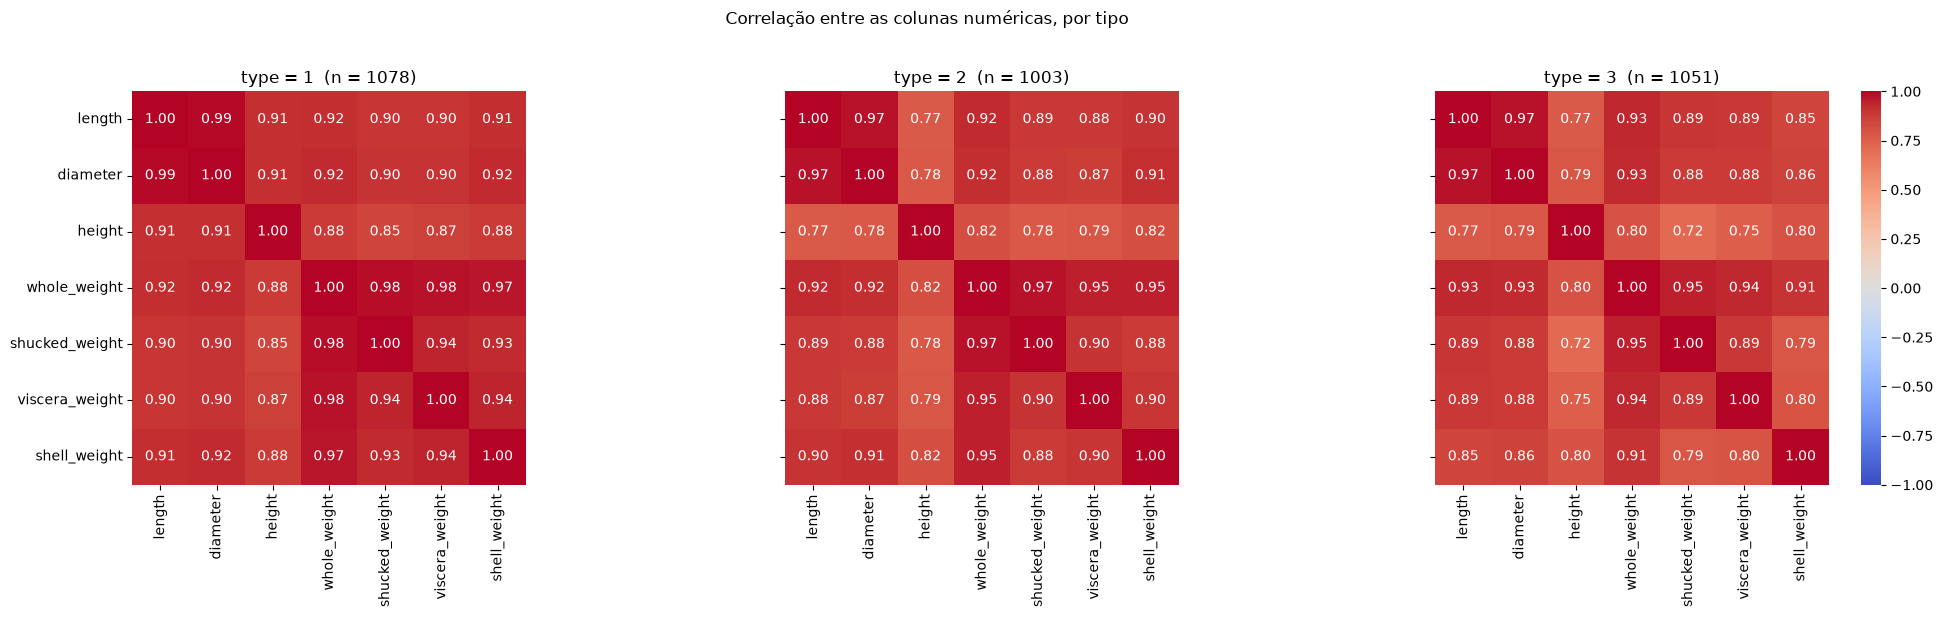

In [7]:
fig, axes = plt.subplots(1, len(tipos), figsize=(7 * len(tipos), 6), sharey=True)

for ax, t in zip(axes, tipos):
    corr = df.loc[df["type"] == t, colunas_numericas].corr()
    sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm",
                vmin=-1, vmax=1, square=True, cbar=(t == tipos[-1]), ax=ax)
    ax.set_title(f"type = {t}  (n = {(df['type'] == t).sum()})")

plt.suptitle("Correlação entre as colunas numéricas, por tipo", y=1.02)
plt.tight_layout()
plt.show()

## Tabela: quanto cada par de colunas varia entre os tipos

Mostra a correlação de cada par em cada tipo e a diferença entre o maior e o menor valor, ordenada da maior diferença para a menor.

In [4]:
linhas = []
for i, a in enumerate(colunas_numericas):
    for b in colunas_numericas[i + 1:]:
        linha = {"par": f"{a} x {b}"}
        for t in tipos:
            linha[f"type {t}"] = df.loc[df["type"] == t, [a, b]].corr().iloc[0, 1]
        valores = [linha[f"type {t}"] for t in tipos]
        linha["diferença"] = max(valores) - min(valores)
        linhas.append(linha)

tabela = pd.DataFrame(linhas).sort_values("diferença", ascending=False).reset_index(drop=True)
tabela.round(2)

,par,type 1,type 2,type 3,diferença
0,viscera_weight x shell_weight,0.94,0.90,0.80,0.15
1,shucked_weight x shell_weight,0.93,0.88,0.79,0.14
2,length x height,0.91,0.77,0.77,0.14
3,diameter x height,0.91,0.78,0.79,0.13
4,height x shucked_weight,0.85,0.78,0.72,0.13
5,height x viscera_weight,0.87,0.79,0.75,0.11
6,height x whole_weight,0.88,0.82,0.80,0.08
7,height x shell_weight,0.88,0.82,0.80,0.08
8,diameter x shell_weight,0.92,0.91,0.86,0.07
9,length x shell_weight,0.91,0.90,0.85,0.07
